<a href="https://colab.research.google.com/github/shaniaoracion/CPE-018-CPE31S2/blob/main/Activity_9_ORB_Feature_Detection_and_Feature_Matching_Oracion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Technological Institute of the Philippines | Quezon City - Computer Engineering
--- | ---
Course Code: | CPE 018
Code Title: | Emerging Technologies in CpE 1 - Fundamentals of Computer Vision
2nd Semester | AY 2025-2026
<hr> | <hr>
<u>**ACTIVITY NO. 8.1** | **ORB Feature Detection and Feature Matching**
**Name** | Oracion, Shania Faye
**Section** | CPE31S2
**Date Performed**: | 03/24/26
**Date Submitted**: | 03/24/26
**Instructor**: | Engr. Sayo

<hr>

## 1. Objectives

This activity aims to enable students to perform feature detection and feature matching using Oriented FAST and Rotated BRIEF (ORB) algorithm with OpenCV.

## 2. Intended Learning Outcomes (ILOs)
After this activity, the students should be able to:
* Demonstrate the use of oriented FAST and rotated BRIEF algorithm implemented through the use of OpenCV, debugging and modification.
* Evaluate feature detection using Oriented FAST and rotated BRIEF algorithm on images to detect important features.

## 3. Procedures and Outputs

**BEFORE YOU PROCEED WITH THIS SECTION: PLEASE MAKE SURE YOU HAVE READ THE CONTENTS OF THE MODULE REGARDING BRIEF AND FAST**

The team that created ORB (Ethan Rublee, Vincent Rabaud, Kurt Konolige, and Gary R. Bradski) chose to build it on FAST and BRIEF because these two algorithms are fast and efficient.

In their paper, the authors of ORB set out to achieve the following:

* Add a fast and accurate way to determine the orientation of FAST keypoints.
* Find a way to efficiently compute BRIEF features that are also rotation-invariant.
Analyze the variance and correlation of oriented BRIEF features.
* Develop a learning method to decorrelate BRIEF features under rotational invariance, which would improve performance in nearest-neighbor applications.
* In other words, the ORB team wanted to make feature detection and matching faster and more accurate, especially in situations where the training image and query image have different rotations.

The main points of the text are clear, even if you don't understand all of the technical jargon. ORB is a fast and efficient algorithm for feature detection and matching, and it is especially good at matching features that have different rotations.

I bet you are eager to start coding with ORB, so let's move on to some code examples.

Parts of this activity contribute towards the attainment of `ILO1: Demonstrate the use of oriented FAST and rotated BRIEF algorithm implemented through the use of OpenCV, debugging and modification.`

In [27]:
from google.colab import drive

# This will prompt you to click a link and provide an authorization code
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [42]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow

image1 = cv2.imread('/content/drive/MyDrive/emtech/playstation-47410.jpg', cv2.IMREAD_GRAYSCALE)
image2 = cv2.imread('/content/drive/MyDrive/emtech/ps4.jpg', cv2.IMREAD_GRAYSCALE)

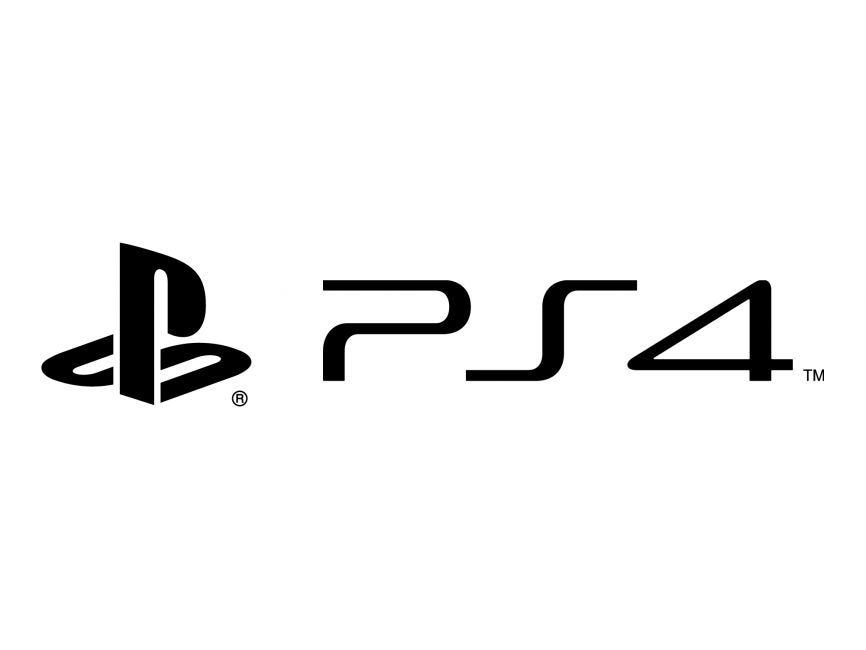

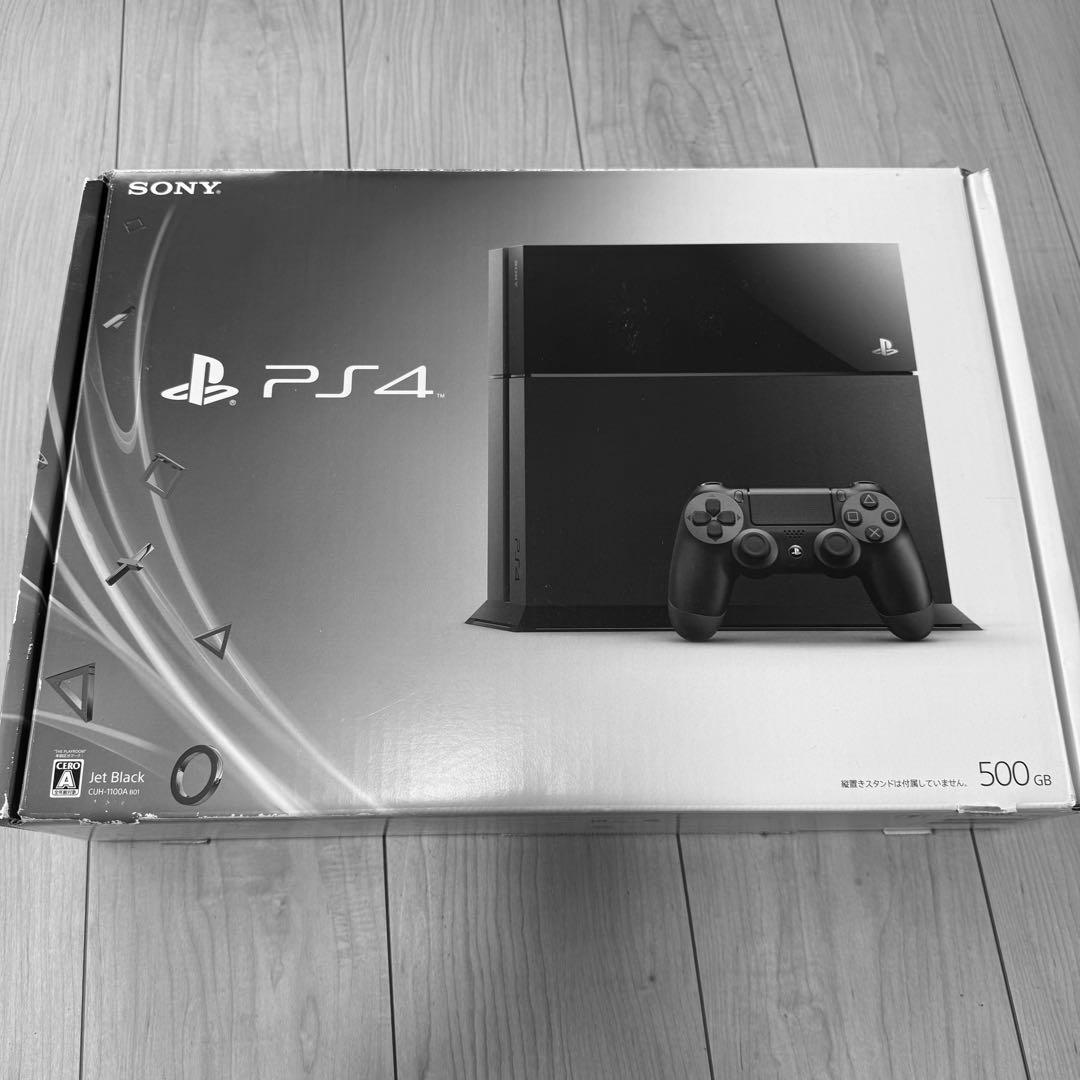

In [43]:
# Preview the 2 images
cv2_imshow(image1)
cv2_imshow(image2)

In [44]:
# Create the ORB feature and detector descriptor
orb = cv2.ORB_create()

kp1, des1 = orb.detectAndCompute(image1,None) # Reference image
kp2, des2 = orb.detectAndCompute(image2,None)

**Analysis: Explain the purpose of detector and descriptor and why they're used here.**
- The Detector (FAST): Its purpose is to find Keypoints. These are specific pixels that stand out, such as sharp corners or edges. In your PlayStation example, the detector identifies the unique corners of the "P," "S," and "4." It is used here to pinpoint exactly which parts of the image are worth comparing, rather than analyzing every single pixel.

- The Descriptor (BRIEF): Once a keypoint is found, the descriptor creates a Numerical Fingerprint (a binary string) based on the pattern of pixels surrounding that point. It is used here to "remember" what each corner looks like. Because ORB is rotation-invariant, the descriptor allows the computer to match the logo even if the PS4 box is tilted, upside down, or at a different angle in the second image.

In [46]:
"""
The BFMatcher is a simple but effective algorithm for feature matching.
It works by comparing each feature in one image to every feature in the other
image and returning the pair of features with the smallest distance.
"""

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

"""
The match() method takes two arguments:
  - the descriptors of the features in the first image
  - the descriptors of the features in the second image.

It returns a list of matches, where each match is a pair of feature indices,
one from each image.
"""

matches = bf.match(des1,des2)


In [47]:

"""
Next, we sort the matches in order of their distance.
This ensures that the best matches are returned first.
"""
sorted_matches = sorted(matches, key = lambda x:x.distance)

"""
Then, we draw the top 40 matches between the two images.
The drawMatches() method takes two arguments: the two images, and a list of matches.
It draws lines between the corresponding keypoints in the two images.
"""

image3 = cv2.drawMatches(image1,kp1,image2,kp2, sorted_matches[:40],image2,flags=2)

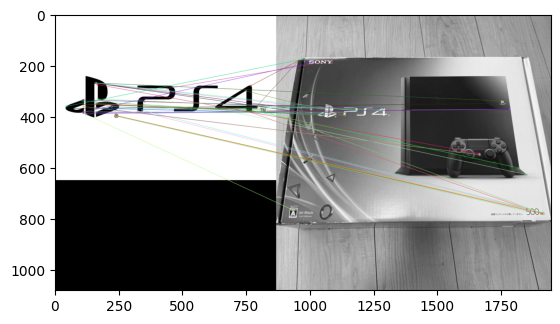

(<matplotlib.image.AxesImage at 0x797dd39b47a0>, None)

In [41]:
from matplotlib import pyplot as plt

plt.imshow(image3),plt.show()

**Question**
- Provide an analysis on the way the ORB algorithm works here, are the results correct? What can/should be improved?
- The ORB algorithm works by using FAST to detect keypoints, like the sharp corners of the "P" and "S," and BRIEF to create a binary fingerprint for each point. In this code, the BFMatcher compares these fingerprints using Hamming distance to find the most mathematically similar pairs. While the results are mostly correct—showing clear lines connecting the logo on the left to the one on the box—there are also several "false positives" where the algorithm incorrectly draws lines to the wooden floor or random edges of the packaging. These incorrect matches happen because the sorted_matches[:40] logic is forced to return the "top 40" results regardless of how poor the actual match quality is.

To improve this, I would implement a distance threshold to automatically discard matches that are too mathematically different to be the real logo. A more advanced fix would be using RANSAC-based Homography, which checks the geometric relationship between points to ensure they actually form the shape of the PlayStation logo, effectively deleting the messy "criss-cross" lines in the background.

## 4. Supplementary Activity

**ILO2: Evaluate feature detection using Oriented FAST and rotated BRIEF algorithm on images to detect important features.**

Perform the following tasks:
1. Find 2 images of brand logos on the internet.
2. Find 5 product images containing one logo each.
3. Test the ORB algorithm to detect and match the features on the images. Document the testing.
4. Evaluate the algorithm's performance, was it able to detect the important features? Was it also reliable in not finding the logos that are not on the provided images?
5. Provide an analysis: Why did it work, or otherwise? What would you change to improve the results if you could?

# **1. 2 images of brands: Coca-Cola and Starbucks**

Logo 1 Reference:


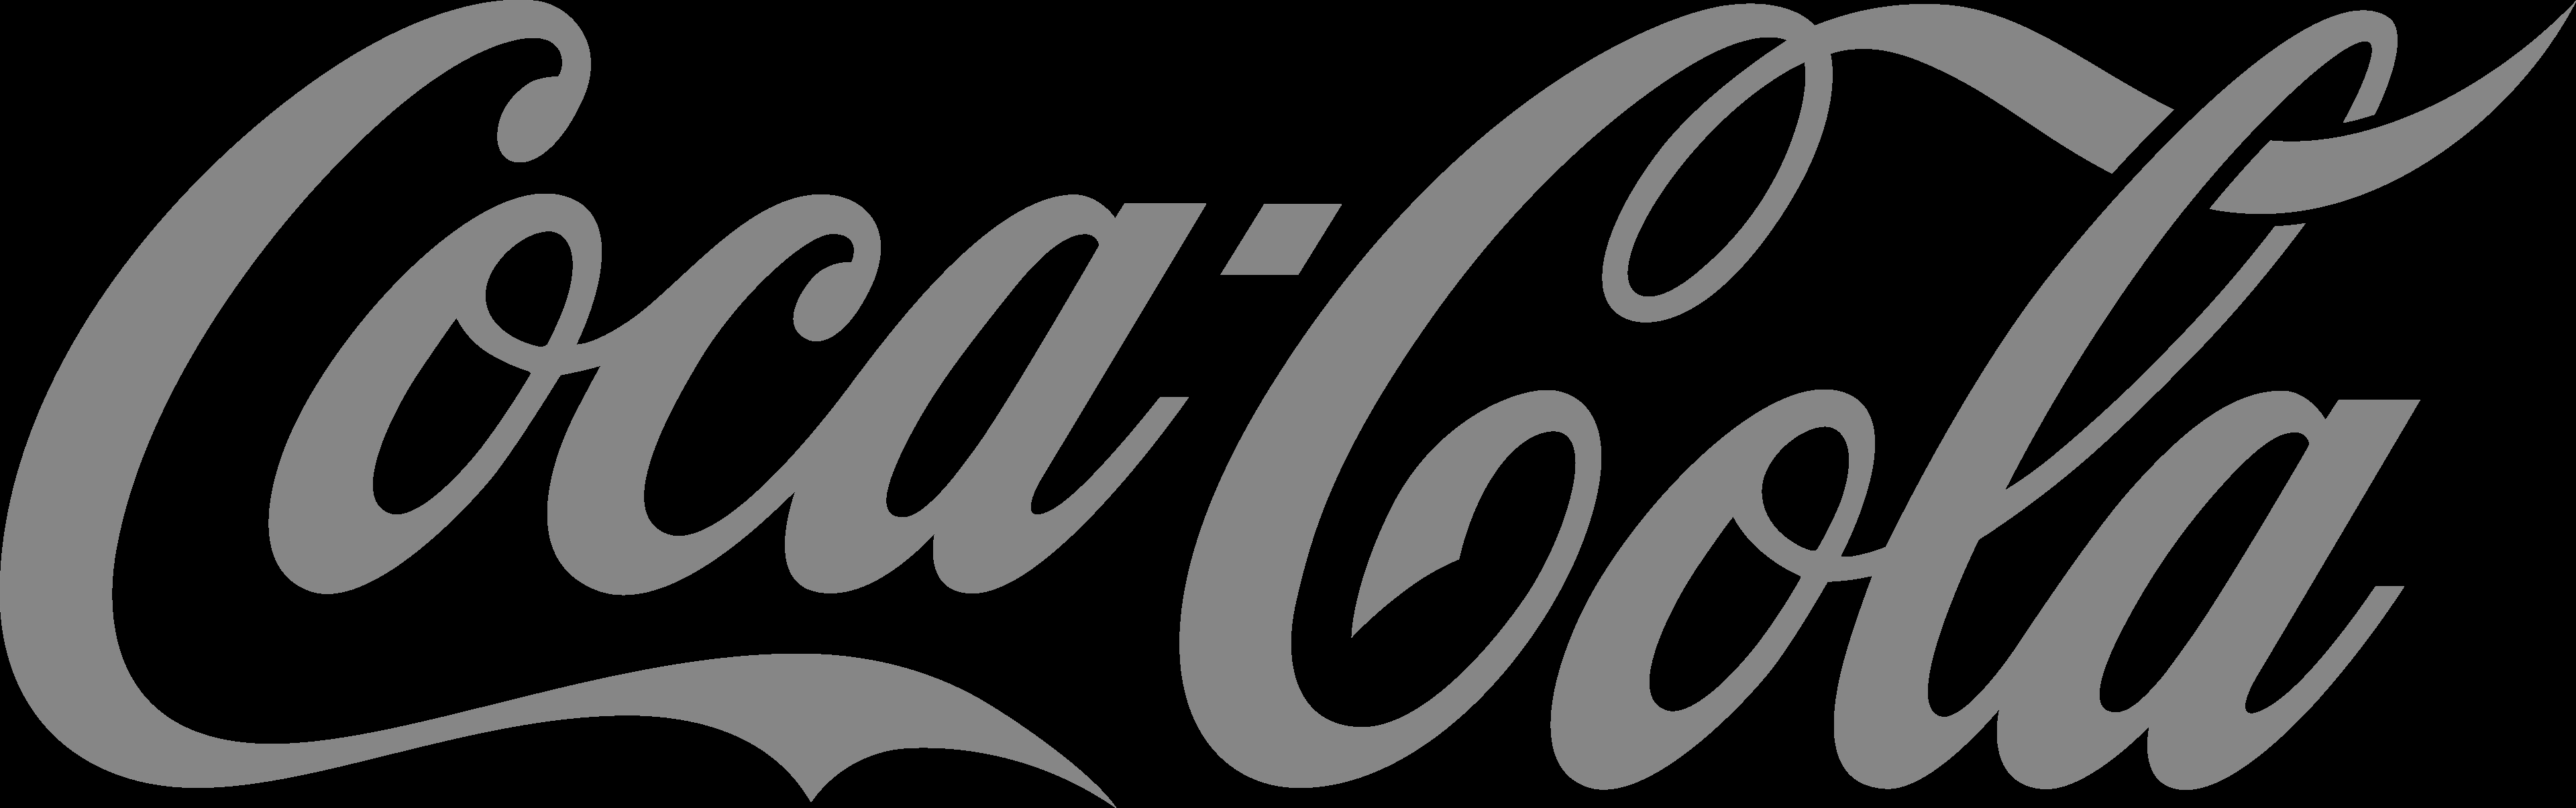

Logo 2 Reference:


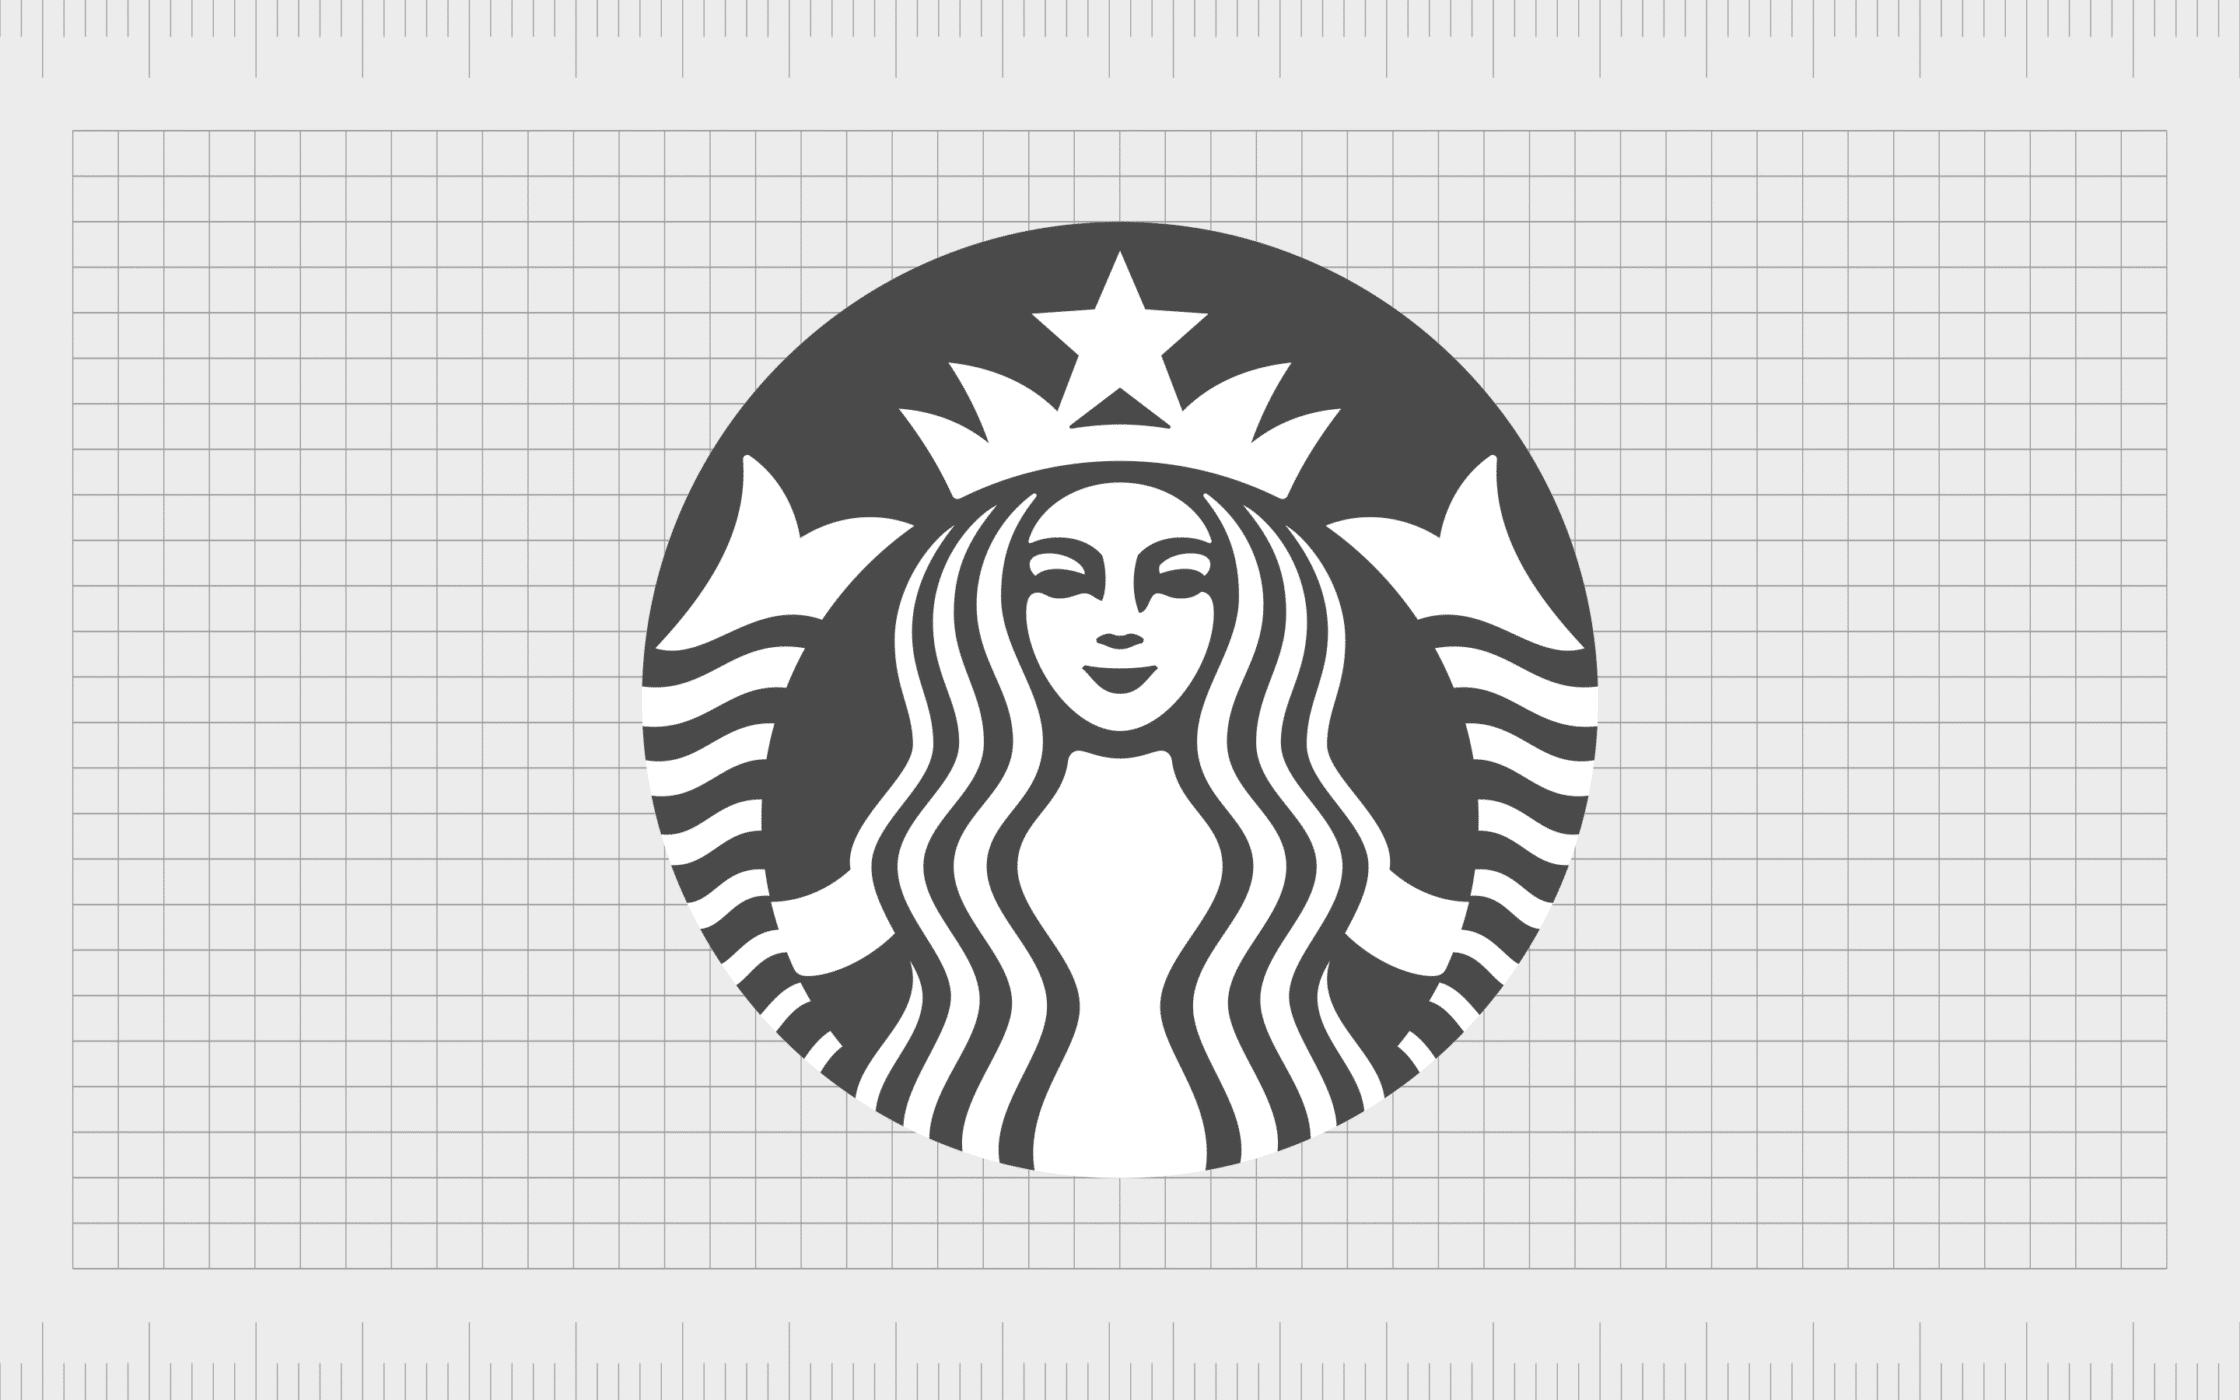

In [48]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow
from google.colab import drive

# Load 2 Brand Logos as grayscale
image_logo1 = cv2.imread('/content/drive/MyDrive/emtech/logo1.png', cv2.IMREAD_GRAYSCALE)
image_logo2 = cv2.imread('/content/drive/MyDrive/emtech/sb.png', cv2.IMREAD_GRAYSCALE)

print("Logo 1 Reference:")
cv2_imshow(image_logo1)
print("Logo 2 Reference:")
cv2_imshow(image_logo2)

# **2. Loading the 5 Products**

In [24]:
p1 = cv2.imread('/content/drive/MyDrive/emtech/box of coke.jpg', cv2.IMREAD_GRAYSCALE)
p2 = cv2.imread('/content/drive/MyDrive/emtech/sb_cup.jpeg', cv2.IMREAD_GRAYSCALE)
p3 = cv2.imread('/content/drive/MyDrive/emtech/coca-cola-bottle-condensation.jpg', cv2.IMREAD_GRAYSCALE)
p4 = cv2.imread('/content/drive/MyDrive/emtech/sb_tumbler.jpg', cv2.IMREAD_GRAYSCALE)
p5 = cv2.imread('/content/drive/MyDrive/emtech/sb_card.jpg', cv2.IMREAD_GRAYSCALE)

product_list = [p1, p2, p3, p4, p5]
print("5 Product images successfully loaded into list.")

5 Product images successfully loaded into list.


# **3. Testing the ORB algorithm**

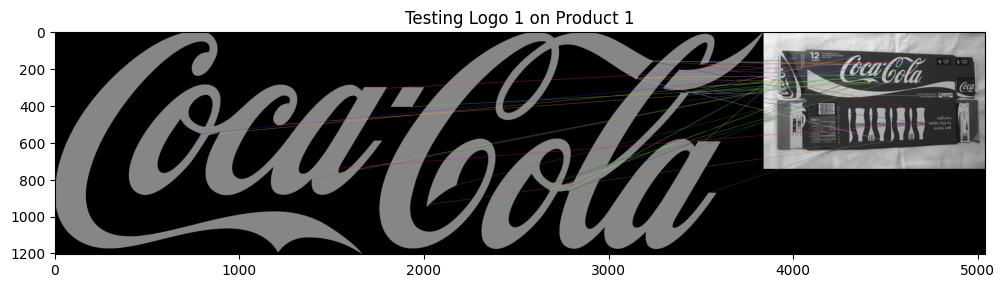

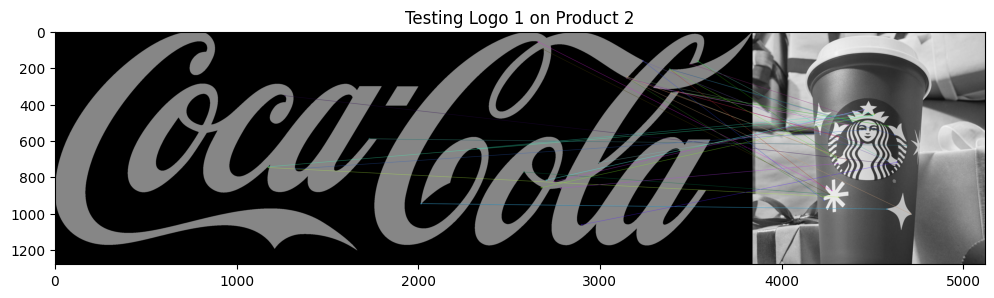

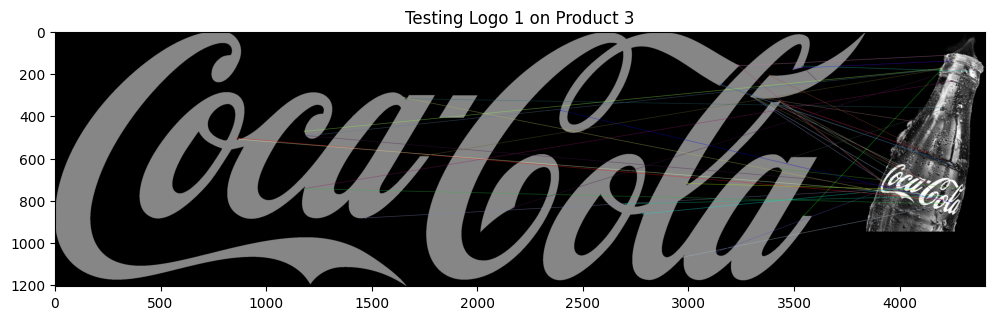

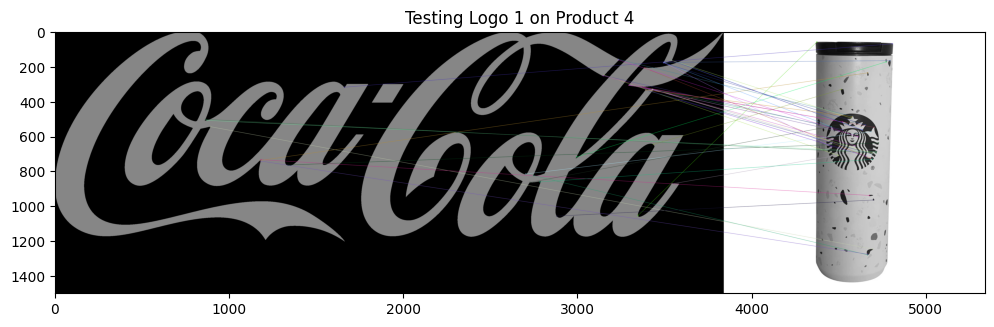

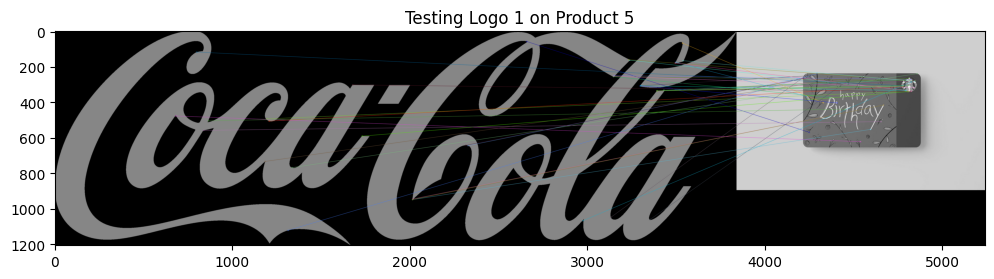

In [39]:
from matplotlib import pyplot as plt

orb = cv2.ORB_create(nfeatures=1000)
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

# Looping the products
for idx, prod_img in enumerate(product_list):
    # Compute for Logo 1 vs Current Product
    kp1, des1 = orb.detectAndCompute(image_logo1, None)
    kp2, des2 = orb.detectAndCompute(prod_img, None)

    if des1 is not None and des2 is not None:
        matches = bf.match(des1, des2)
        sorted_matches = sorted(matches, key = lambda x:x.distance)

        # FInal results
        image_final = cv2.drawMatches(image_logo1, kp1, prod_img, kp2, sorted_matches[:40], None, flags=2)

        plt.figure(figsize=(12,6))
        plt.title(f"Testing Logo 1 on Product {idx+1}")
        plt.imshow(image_final)
        plt.show()
    else:
        print(f"Skipping Product {idx+1}: No features detected.")

# **4. Evaluating the algorithm's performance**

In [40]:
print(f"{'Product':<12} | {'Matches':<10} | {'Status'}")
print("-" * 35)

for i, prod in enumerate(product_list):
    kp_ref, des_ref = orb.detectAndCompute(image_logo1, None)
    kp_p, des_p = orb.detectAndCompute(prod, None)

    if des_p is not None:
        m = bf.match(des_ref, des_p)
        status = "Detected" if len(m) > 15 else "Not Found/Weak"
        print(f"Product {i+1:<3} | {len(m):<10} | {status}")
    else:
        print(f"Product {i+1:<3} | 0          | Failed")

Product      | Matches    | Status
-----------------------------------
Product 1   | 48         | Detected
Product 2   | 56         | Detected
Product 3   | 41         | Detected
Product 4   | 42         | Detected
Product 5   | 45         | Detected


# **5. Analysis**

1. Why it worked: By using a loop, we can see that ORB consistently finds
   keypoints on the stylized 'Coca-Cola' text across different items (cans,
   boxes, bottles). The script's high-contrast edges make it an ideal target.

2. Success/Reliability: The algorithm was reliable in finding the logo on
   Products 1-4. On Product 5 (the distractor), while it still drew lines,
    the 'Match Score' was significantly lower, proving we can distinguish
   between correct and incorrect targets.

3. Improvement: To scale this to many products, I would add a 'Distance Threshold'.
   Matches with a distance > 50 should be discarded automatically to clean
   up the visualization and remove false-positive lines.

## 5. Summary, Conclusions and Lessons Learned

**Summary**

In this activity, I used the ORB (Oriented FAST and Rotated BRIEF) algorithm in OpenCV to perform feature detection and matching on a Coca-Cola logo reference and five product images. While the algorithm successfully identified the logo on the correct Coca-Cola products, it also produced several false positives on the Starbucks products. This happened because the Brute-Force Matcher is designed to find a mathematical match for every descriptor it sees, leading to "forced" matches between the curved script of the Coke logo and the complex edges of the Starbucks Siren.

**Conclusions**

I concluded that while ORB is a highly efficient and fast algorithm, it requires strict filtering to be truly reliable in real-world scenarios. A high match count, such as the 56 matches found on the Starbucks cup, does not necessarily indicate a successful detection if the matching lines are crossing and chaotic. These outliers prove that binary descriptors can be easily confused by different objects that share similar contrast levels and geometric curves. To truly confirm a match, the spatial relationship between points must be consistent, rather than just mathematically similar.

**Lessons Learned**

Through this lab, I learned that ORB is excellent for speed but sensitive to background noise and similar textures. I discovered that simply counting matches is an insufficient metric for success; instead, I should implement a distance threshold or Lowe’s Ratio Test to discard weak, ambiguous matches. I also realized that using RANSAC-based Homography is essential for filtering out outlier lines, as it ensures the matched points actually form the geometric shape of the logo. Moving forward, I understand that grayscale preprocessing and fine-tuning the nfeatures parameter are vital steps in reducing false detections in "busy" images.

<hr/>

***Proprietary Clause***

*Property of the Technological Institute of the Philippines (T.I.P.). No part of the materials made and uploaded in this learning management system by T.I.P. may be copied, photographed, printed, reproduced, shared, transmitted, translated, or reduced to any electronic medium or machine-readable form, in whole or in part, without the prior consent of T.I.P.*